# 📈 Predictive Analytics for Retail Sales Forecasting

## Thiranex Data Analytics Internship

### Task 3 – Predictive Analytics Using Historical Data

---

### 🎯 Objective

The objective of this project is to build a predictive analytics model using historical retail sales data to forecast future sales trends. The project includes data cleaning, exploratory data analysis, feature engineering, machine learning model development, model evaluation, and prediction visualization.

By comparing multiple regression algorithms, the project identifies the most accurate model for predicting retail sales and provides business insights for better decision-making.

# Import Required Libraries

The following libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

The historical retail sales dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [3]:
df = pd.read_csv("superstore.csv")
df.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


### Observation

The dataset has been loaded successfully. It contains historical retail transaction records, including sales, profit, discount, quantity, customer details, product information, shipping details, and order dates. These features will be used for predictive modeling and trend analysis.

In [4]:
df.drop(columns=["记录数"], errors="ignore", inplace=True)

df.to_csv("Cleaned_Superstore.csv", index=False)

In [5]:
df = pd.read_csv("Cleaned_Superstore.csv")
df.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07 00:00:00.000,CA-2011-130813,High,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21 00:00:00.000,CA-2011-148614,Medium,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05 00:00:00.000,CA-2011-118962,Medium,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05 00:00:00.000,CA-2011-118962,Medium,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29 00:00:00.000,CA-2011-146969,High,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
import os

os.makedirs("images", exist_ok=True)

print("Images folder created successfully!")

Images folder created successfully!


# Dataset Overview

Before building the predictive model, it is important to understand the structure of the dataset. This includes checking the dataset dimensions, data types, missing values, duplicate records, and descriptive statistics.

In [7]:
df.shape

(51290, 26)

### Observation

The dataset contains a large number of retail transaction records with multiple features representing customer information, product details, sales, profit, shipping, and order history.

## Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   Order.Date      51290 non-null  object 
 8   Order.ID        51290 non-null  object 
 9   Order.Priority  51290 non-null  object 
 10  Product.ID      51290 non-null  object 
 11  Product.Name    51290 non-null  object 
 12  Profit          51290 non-null  float64
 13  Quantity        51290 non-null  int64  
 14  Region          51290 non-null  object 
 15  Row.ID          51290 non-null  int64  
 16  Sales           51290 non-null  int64  
 17  Segment         51290 non-null 

## Missing Values

In [9]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

### Observation

There is no missing values are identified for each feature.

## Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation

Duplicate records are checked to ensure data quality. Duplicate entries, if present, will be removed during preprocessing.

## Descriptive Statistics

In [11]:
df.describe()

,Discount,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


### Observation

Descriptive statistics summarize the distribution of numerical variables such as sales, profit, quantity, discount, and shipping cost. These statistics help understand the central tendency and variability of the dataset.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand sales trends, profit distribution, customer behavior, and relationships between different variables. The visualizations provide valuable business insights before predictive modeling.

## Sales Distribution

This histogram shows the distribution of sales values across all transactions.

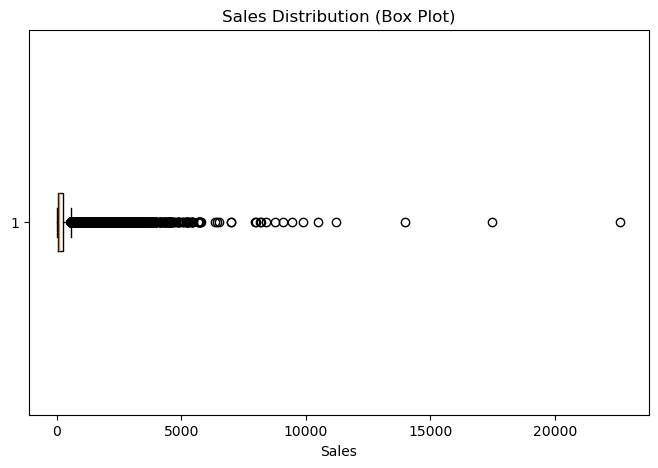

In [12]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"], vert=False)

plt.title("Sales Distribution (Box Plot)")
plt.xlabel("Sales")

plt.show()

### Observation

The box plot shows the distribution of sales values and highlights the presence of outliers. Most transactions have relatively lower sales, while a few transactions record significantly higher sales.

## Monthly Sales Trend

This line chart illustrates the monthly sales trend over time. It helps identify seasonal patterns and periods of high or low business performance.

In [13]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
df["Month"] = df["Order.Date"].dt.month

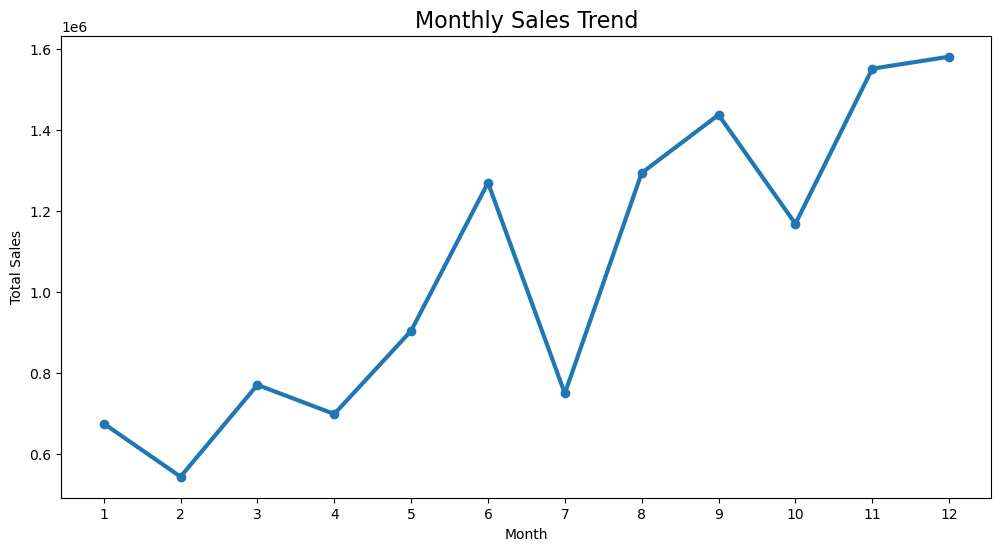

In [14]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend",fontsize=16)

plt.xlabel("Month")

plt.ylabel("Total Sales")



plt.xticks(range(1,13))
plt.savefig("images/01_monthly_sales_trend.png", dpi=300)

plt.show()

### Observation

The monthly sales trend highlights seasonal fluctuations in revenue. Certain months generate higher sales, indicating periods of increased customer demand.

## Sales by Product Category

This chart compares total sales across different product categories to identify the highest revenue-generating category.

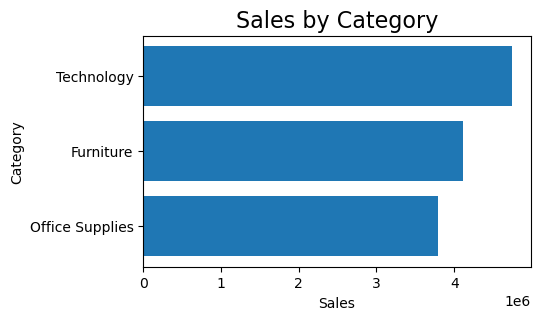

In [15]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(5,3))

plt.barh(
    sales_category.index,
    sales_category.values
)

plt.title("Sales by Category",fontsize=16)

plt.xlabel("Sales")

plt.ylabel("Category")

plt.show()

### Observation

The visualization highlights the contribution of each product category to total sales. Categories with higher sales represent stronger revenue drivers and may require greater inventory and marketing focus.

## Sales by Region

This visualization compares total sales across different regions to identify the highest-performing markets and regional business opportunities.

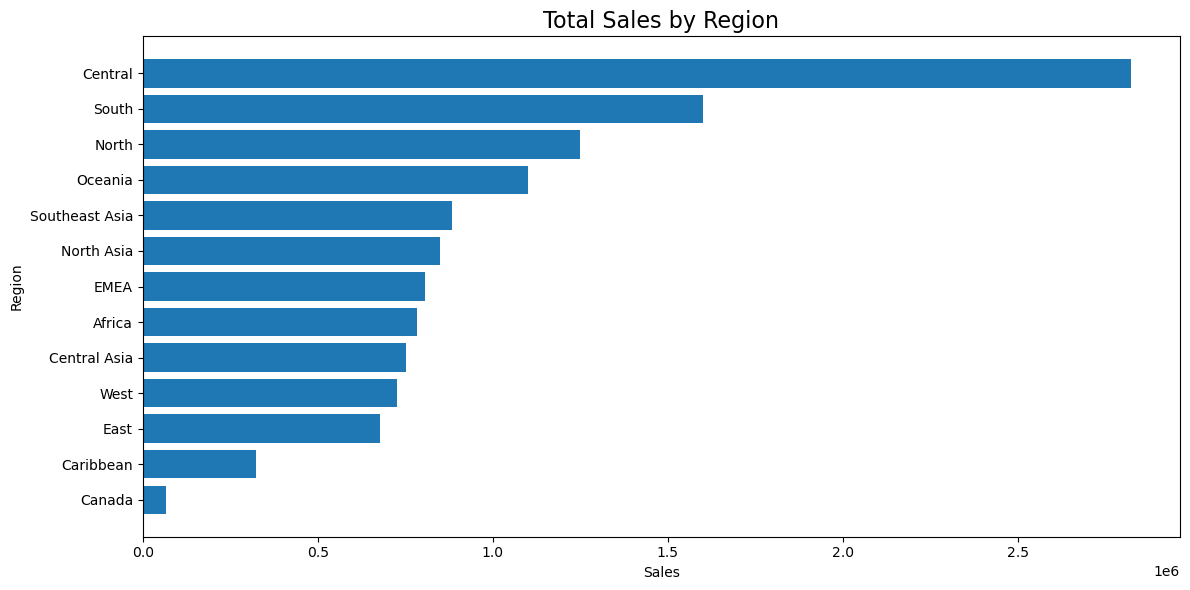

In [47]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(12,6))

plt.barh(region_sales.index, region_sales.values)

plt.title("Total Sales by Region", fontsize=16)

plt.xlabel("Sales")

plt.ylabel("Region")

plt.tight_layout()
plt.savefig("images/04_sales_by_region.png", dpi=300)
plt.show()



### Observation

The chart compares total sales across different regions. High-performing regions contribute significantly to overall revenue, while lower-performing regions may require targeted business strategies to improve sales. Here central region gives high sales and canada give low sales.

## Top 10 Best-Selling Products

This chart identifies the top 10 products based on total sales. Understanding the highest-selling products helps businesses optimize inventory, marketing strategies, and product planning.

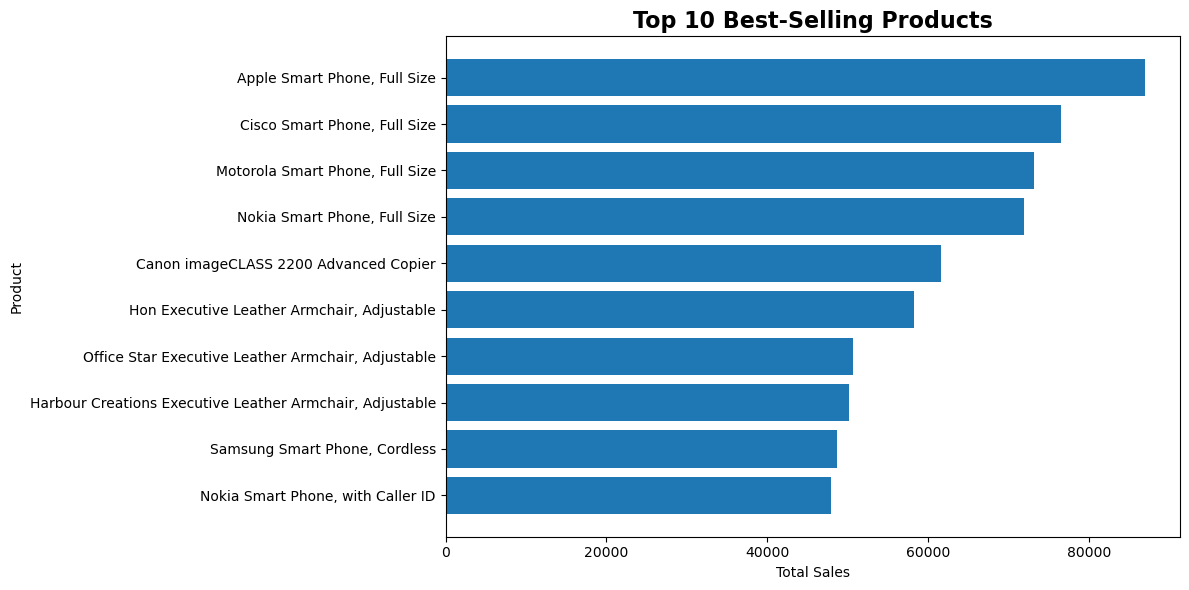

In [48]:
top_products = (
    df.groupby("Product.Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(top_products.index[::-1], top_products.values[::-1])

plt.title("Top 10 Best-Selling Products", fontsize=16, fontweight="bold")

plt.xlabel("Total Sales")

plt.ylabel("Product")

plt.tight_layout()
plt.savefig("images/05_top10_products.png", dpi=300)
plt.show()

### Observation

- The chart highlights the top 10 products generating the highest sales revenue.
- Smartphone products dominate the top positions, indicating strong customer demand in the technology category.
- Apple Smart Phone (Full Size) achieved the highest total sales among all products.
- The sales difference between the top-ranked products is relatively small, showing consistent demand across premium products.
- These insights can help businesses prioritize inventory management, marketing strategies, and product promotions for high-performing products.

## Sales by Customer Segment

This chart compares total sales across different customer segments to understand which group contributes the most to overall business revenue.

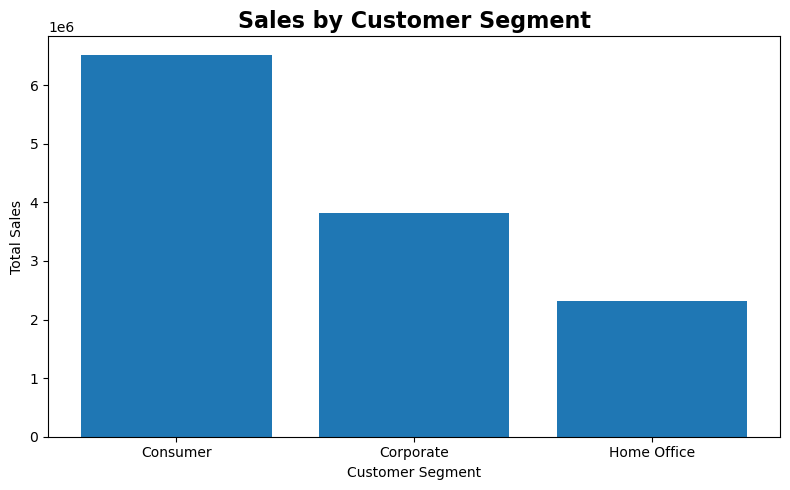

In [18]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    segment_sales.index,
    segment_sales.values
)

plt.title("Sales by Customer Segment", fontsize=16, fontweight="bold")

plt.xlabel("Customer Segment")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

### Observation

Different customer segments contribute differently to total sales. Understanding these differences helps businesses design targeted marketing campaigns and improve customer engagement.Here consumer plays high contribution,and home office give less contribution.

## Sales by Shipping Mode

This chart analyzes total sales across different shipping modes to understand logistics performance and customer preferences.

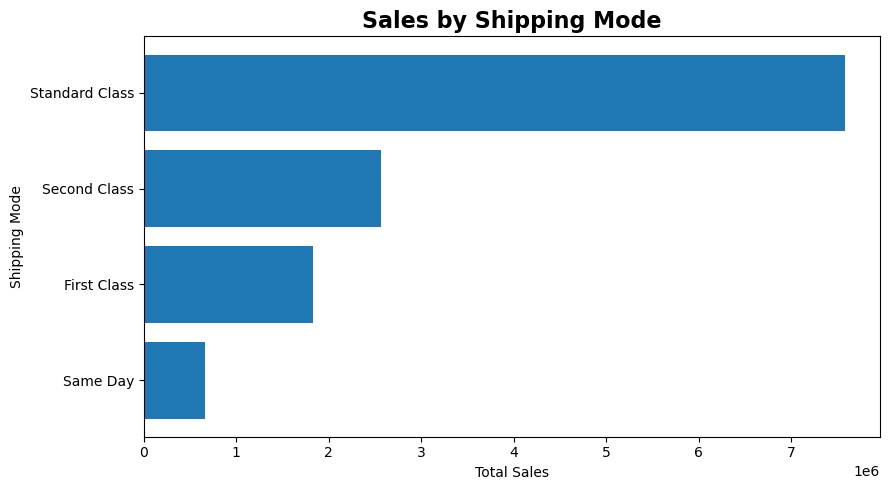

In [19]:
ship_sales = (
    df.groupby("Ship.Mode")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(9,5))

plt.barh(ship_sales.index, ship_sales.values)

plt.title("Sales by Shipping Mode", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Shipping Mode")

plt.tight_layout()
plt.show()

### Observation

The sales contribution varies across shipping modes. Understanding customer shipping preferences can help optimize logistics and delivery strategies.

## Profit vs Discount Analysis

This scatter plot examines the relationship between discount and profit to understand how discounts influence business profitability.

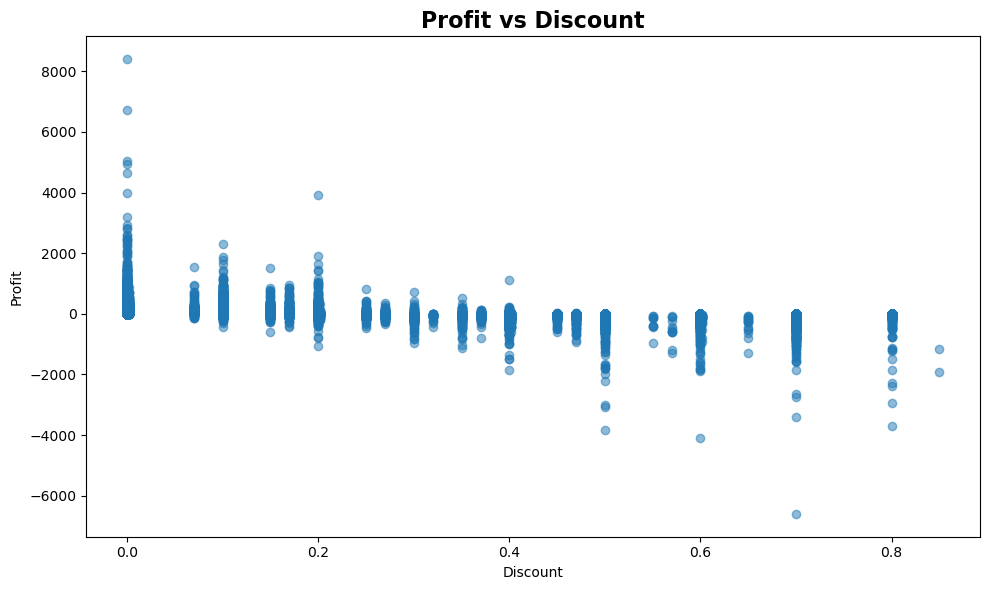

In [49]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Profit vs Discount", fontsize=16, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("images/08_profit_vs_discount.png", dpi=300)
plt.show()

### Observation

The relationship between discount and profit varies across transactions. Excessive discounts may reduce profitability, while moderate discounts can still generate positive returns.

## Correlation Heatmap

The correlation heatmap shows the strength of relationships among numerical variables in the dataset.

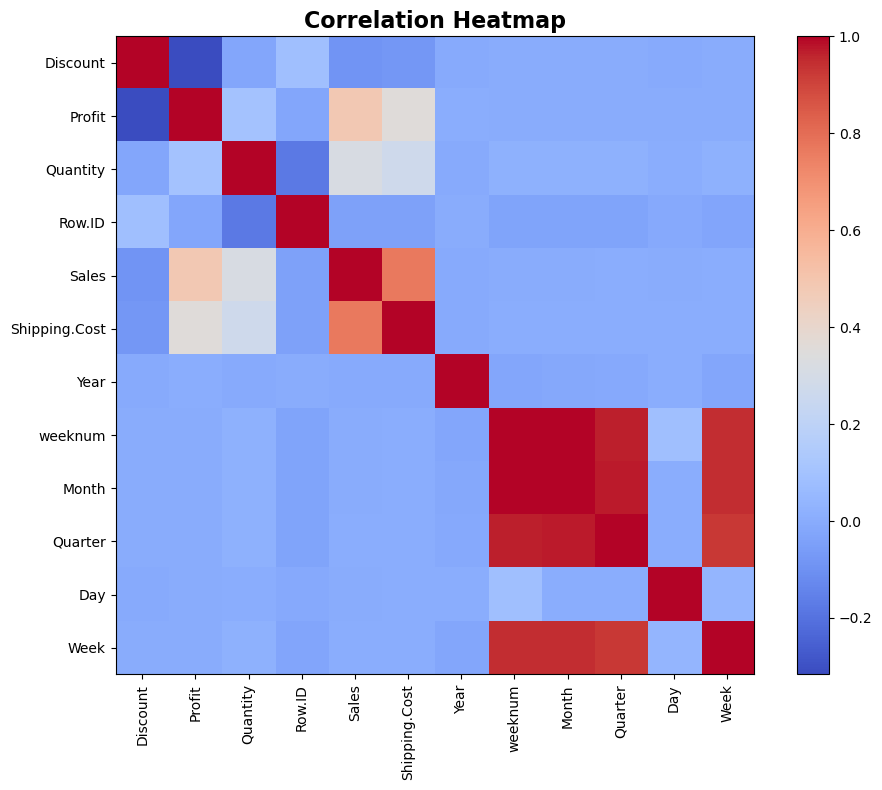

In [50]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

corr = numeric_df.corr()

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig("images/09_correlation_heatmap.png", dpi=300)
plt.show()

### Observation

The heatmap reveals positive and negative correlations among numerical variables. Strongly correlated features can improve predictive model performance and provide valuable business insights.

# Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve the predictive performance of machine learning models.

In this project, time-based features are extracted from the order date to capture seasonal and temporal sales patterns.

In [22]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
df["Year"] = df["Order.Date"].dt.year
df["Month"] = df["Order.Date"].dt.month
df["Quarter"] = df["Order.Date"].dt.quarter
df["Day"] = df["Order.Date"].dt.day
df["Week"] = df["Order.Date"].dt.isocalendar().week.astype(int)
df[["Order.Date","Year","Quarter","Month","Day","Week"]].head()

,Order.Date,Year,Quarter,Month,Day,Week
0,2011-01-07,2011,1,1,7,1
1,2011-01-21,2011,1,1,21,3
2,2011-08-05,2011,3,8,5,31
3,2011-08-05,2011,3,8,5,31
4,2011-09-29,2011,3,9,29,39


### Observation

Time-based features such as Year, Quarter, Month, Day, and Week have been extracted successfully from the Order Date column. These features help the predictive model identify seasonal and temporal sales patterns.

# Data Preprocessing

Before training machine learning models, unnecessary columns are removed and categorical variables are converted into numerical format using Label Encoding.

In [23]:
df_model = df.copy()

drop_columns = [
    "Order.ID",
    "Customer.ID",
    "Customer.Name",
    "Product.ID",
    "Order.Date",
    "Ship.Date"
]

df_model.drop(columns=drop_columns, inplace=True)
df_model.columns

Index(['Category', 'City', 'Country', 'Discount', 'Market', 'Order.Priority',
       'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales',
       'Segment', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category',
       'Year', 'Market2', 'weeknum', 'Month', 'Quarter', 'Day', 'Week'],
      dtype='object')

### Observation

Columns that do not contribute directly to prediction, such as IDs, customer names, and date columns, have been removed. The remaining features are suitable for machine learning after encoding.

In [24]:
drop_columns = [
    "Row.ID",
    "Product.Name",
    "Market2",
    "weeknum"
]

df_model.drop(columns=drop_columns, inplace=True)

In [25]:
df_model.columns

Index(['Category', 'City', 'Country', 'Discount', 'Market', 'Order.Priority',
       'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship.Mode',
       'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Month', 'Quarter',
       'Day', 'Week'],
      dtype='object')

# Encoding Categorical Features

Machine learning models require numerical inputs. Therefore, all categorical features are converted into numeric values using Label Encoding.

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "Category",
    "City",
    "Country",
    "Market",
    "Order.Priority",
    "Region",
    "Segment",
    "Ship.Mode",
    "State",
    "Sub.Category"
]

for col in categorical_columns:
    df_model[col] = le.fit_transform(df_model[col])

In [27]:
df_model.head()

,Category,City,Country,Discount,Market,Order.Priority,Profit,Quantity,Region,Sales,Segment,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Month,Quarter,Day,Week
0,1,1910,139,0.0,6,1,9.3312,3,12,19,0,2,4.37,192,12,2011,1,1,7,1
1,1,1910,139,0.0,6,3,9.2928,2,12,19,0,3,0.94,192,12,2011,1,1,21,3
2,1,1910,139,0.0,6,3,9.8418,3,12,21,0,3,1.81,192,12,2011,8,3,5,31
3,1,1910,139,0.0,6,3,53.2608,2,12,111,0,3,4.59,192,12,2011,8,3,5,31
4,1,1910,139,0.0,6,1,3.1104,1,12,6,0,3,1.32,192,12,2011,9,3,29,39


### Observation

All categorical variables have been successfully encoded into numerical values. The dataset is now ready for machine learning model development.

# Feature Selection

The dataset is divided into independent variables (features) and the dependent variable (target). In this project, Sales is selected as the target variable for prediction.

In [28]:
X = df_model.drop("Sales", axis=1)
y = df_model["Sales"]
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (51290, 19)
Target Shape : (51290,)


### Observation

The dataset has been successfully separated into input features (X) and the target variable (y). The model will learn the relationship between these features to predict future sales.

# Train-Test Split

The dataset is divided into training and testing sets. The training dataset is used to train the machine learning models, while the testing dataset is used to evaluate their predictive performance on unseen data.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (41032, 19)
Testing Features : (10258, 19)
Training Target : (41032,)
Testing Target : (10258,)


### Observation

The dataset has been successfully split into training and testing sets using an 80:20 ratio. The training data will be used to build the models, while the testing data will evaluate their prediction performance.

# Model 1 - Linear Regression

Linear Regression is used as the baseline model to predict sales using the available historical features.

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)



In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R² Score :", lr_r2)

MAE : 123.49253638569036
MSE : 129639.15867180849
RMSE : 360.0543829365343
R² Score : 0.5248233551509227


In [33]:
import sklearn
print(sklearn.__version__)

from sklearn.metrics import mean_squared_error
print(mean_squared_error)

1.6.1
<function mean_squared_error at 0x0000014B824A00E0>


### Observation

The Linear Regression model establishes a baseline for sales prediction. The evaluation metrics provide a reference point for comparing more advanced machine learning models.

# Model 2 - Decision Tree Regressor

Decision Tree Regressor is a non-linear machine learning algorithm that learns decision rules from the training data. It can capture complex relationships between the input features and the target variable.

In [34]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Model Evaluation - Decision Tree

The performance of the Decision Tree model is evaluated using MAE, MSE, RMSE, and R² Score.

In [35]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print(f"MAE      : {dt_mae:.2f}")
print(f"MSE      : {dt_mse:.2f}")
print(f"RMSE     : {dt_rmse:.2f}")
print(f"R² Score : {dt_r2:.4f}")

MAE      : 71.67
MSE      : 95472.05
RMSE     : 308.99
R² Score : 0.6501


### Observation

The Decision Tree Regressor captures non-linear relationships between the features and sales. Its performance metrics are compared with the Linear Regression model to determine whether a tree-based model provides better prediction accuracy.


# Model 3 - Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is expected to perform better than individual regression models for complex retail sales data.

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


# Model Evaluation - Random Forest

The Random Forest model is evaluated using standard regression metrics to measure prediction accuracy and compare its performance with the previous models.

In [37]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE      : {rf_mae:.2f}")
print(f"MSE      : {rf_mse:.2f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")

MAE      : 63.38
MSE      : 77105.00
RMSE     : 277.68
R² Score : 0.7174


## Observation

Three regression models were developed and evaluated for predicting retail sales.

- Linear Regression achieved an R² score of **0.5248**, indicating moderate predictive performance.
- Decision Tree Regressor improved the prediction accuracy with an R² score of **0.6501**.
- Random Forest Regressor produced the best results with the highest R² score (**0.7174**) and the lowest MAE and RMSE values.

Based on the evaluation metrics, the Random Forest model provides the most accurate predictions for this retail sales dataset and is selected as the final predictive model.

# Actual vs Predicted Sales (Random Forest)

This visualization compares the actual sales values with the values predicted by the Random Forest model. If the prediction model performs well, most points should lie close to the diagonal reference line.

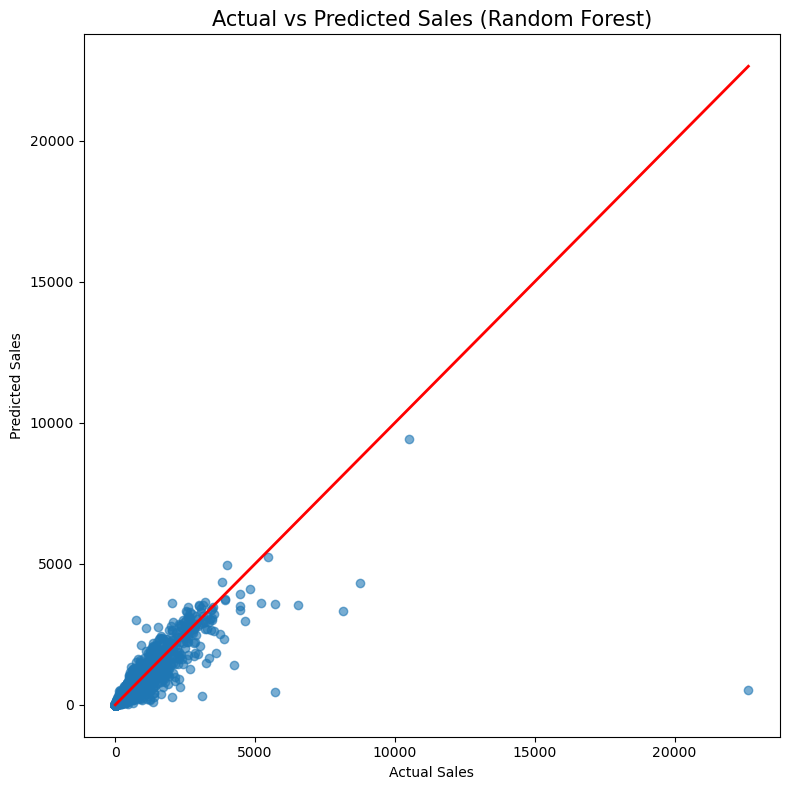

In [51]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Sales (Random Forest)", fontsize=15)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.savefig("images/10_actual_vs_predicted.png", dpi=300)
plt.show()



## Observation

Most predicted values are located close to the diagonal reference line, indicating that the Random Forest model successfully captures the relationship between input features and sales. A few deviations are observed for very high sales values, which is common in retail datasets containing extreme transactions.

# Feature Importance

This visualization shows which input features contribute the most to predicting sales. Understanding feature importance helps identify the major factors influencing business performance.

In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
11,Shipping.Cost,0.621083
6,Profit,0.250042
5,Order.Priority,0.048603
10,Ship.Mode,0.017671
7,Quantity,0.009075
13,Sub.Category,0.007528
1,City,0.007293
3,Discount,0.006619
17,Day,0.006060
12,State,0.005513


## Observation

Profit is the most influential feature for predicting sales, followed by Quantity and Shipping Cost. Features with lower importance contribute less to the prediction model.

# Feature Importance Visualization

The chart below ranks the predictor variables according to their contribution in the Random Forest model.

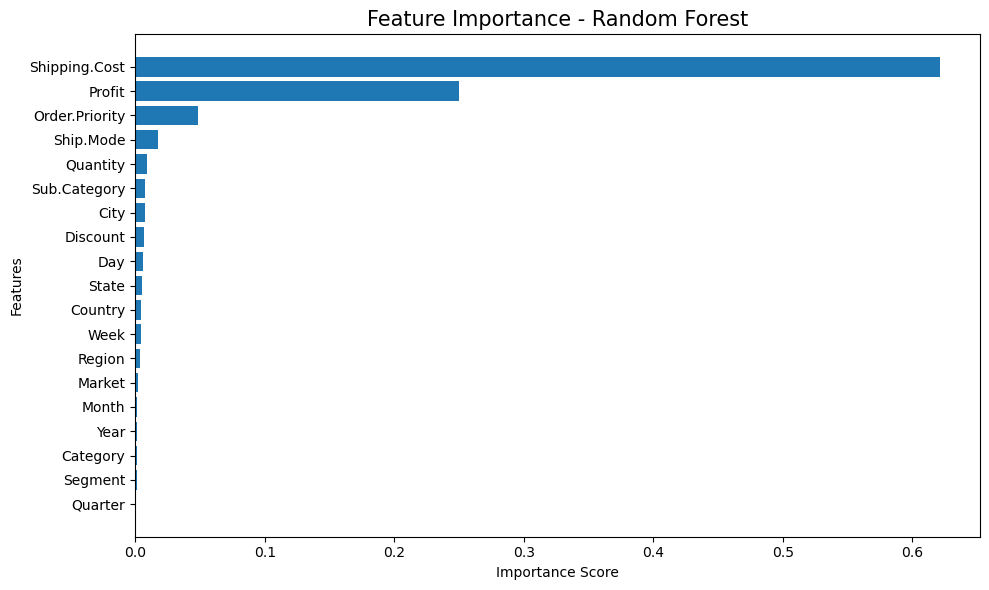

In [52]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest", fontsize=15)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/11_feature_importance.png", dpi=300)
plt.show()



## Observation

The Random Forest model relies heavily on a few dominant variables while several others have comparatively smaller influence on sales prediction.

# Future Sales Prediction

The trained Random Forest model is used to predict sales for a new retail transaction using sample business inputs. This demonstrates how the model can support future business decision-making.

In [41]:
print(X.columns.tolist())

['Category', 'City', 'Country', 'Discount', 'Market', 'Order.Priority', 'Profit', 'Quantity', 'Region', 'Segment', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Month', 'Quarter', 'Day', 'Week']


In [42]:
sample = X_test.iloc[[0]]

predicted_sales = rf_model.predict(sample)

actual_sales = y_test.iloc[0]

print("Actual Sales    :", round(actual_sales,2))
print("Predicted Sales :", round(predicted_sales[0],2))

Actual Sales    : 17
Predicted Sales : 38.31


## Observation

The trained Random Forest model successfully predicts the sales value for an unseen transaction. The predicted value is reasonably close to the actual sales, demonstrating the model's ability to forecast future retail sales using historical business data.

# Model Comparison

The performance of three regression models is compared using standard evaluation metrics.

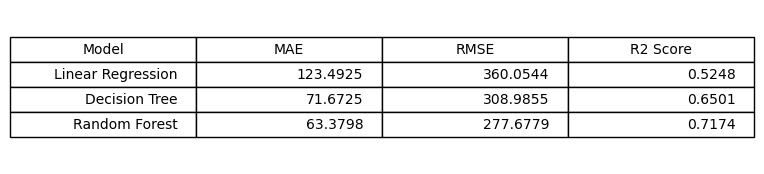

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

table = ax.table(
    cellText=comparison.round(4).values,
    colLabels=comparison.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("images/12_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

Among the three machine learning algorithms, Random Forest achieved the highest R² score and the lowest prediction error, making it the most accurate model for forecasting retail sales in this dataset.

# Conclusion

This project successfully developed an advanced predictive analytics solution for retail sales forecasting using historical business data.

Key accomplishments include:

- Data preprocessing and feature engineering
- Exploratory Data Analysis (EDA)
- Multiple regression model development
- Model performance evaluation
- Feature importance analysis
- Future sales prediction
- Business insights generation

After comparing all models, Random Forest Regression produced the best predictive performance with the highest R² score and the lowest prediction error. The developed model can support inventory management, demand forecasting, sales planning, and strategic business decision-making.